# **===========================================================================================================================================================** #
# **Incremental Capstone 8 - Movies** #
# **===========================================================================================================================================================** #

In [171]:
#Import Statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.base import (
    BaseEstimator, 
    TransformerMixin
)

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    mean_squared_error, 
    root_mean_squared_error, 
    r2_score,
    silhouette_score,
    accuracy_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    classification_report,
    precision_score,
    recall_score,
    balanced_accuracy_score,
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    KBinsDiscretizer,
    PowerTransformer,
    QuantileTransformer,
    MinMaxScaler,
    StandardScaler,
    FunctionTransformer,
    OrdinalEncoder,
    OneHotEncoder,
    LabelEncoder,
    PolynomialFeatures
)

from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression,
    Ridge, 
    Lasso,
    ElasticNet
)

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor
)

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering, 
    FeatureAgglomeration,
    DBSCAN
)

from sklearn.model_selection import(
    train_test_split,
    GridSearchCV,
    cross_val_score,
    KFold
)

from scipy.stats import t
from scipy.stats import (
    boxcox, 
    yeojohnson, 
    shapiro
)

from scipy.cluster.hierarchy import (
    dendrogram, 
    linkage
)

from sklearn.impute import (
    SimpleImputer
)

from sklearn.decomposition import (
    PCA,
    TruncatedSVD
)

from sklearn.manifold import TSNE

from statsmodels.nonparametric.smoothers_lowess import lowess

from kneed import KneeLocator

### **EDA Utility Functions** ###

In [172]:

data_set_name = ''
target_label = ''

def WrapText(text, max_width=15):
    """Wrap text to multiple lines"""
    words = str(text).split()
    lines = []
    current_line = ""
    
    for word in words:
        if len(current_line + " " + word) <= max_width:
            current_line = (current_line + " " + word).strip()
        else:
            if current_line:
                lines.append(current_line)
            current_line = word
    if current_line:
        lines.append(current_line)
    
    return "\n".join(lines)

def DisplayTable(df_target, table_title=None, max_cell_length=30, show_index=False, 
                 wrap_headers=True, header_wrap_width=15, min_height=3,
                 row_height=0.35, font_size=10):

    if df_target.empty:
        print(f"No data to display{': ' + table_title if table_title else ''}")
        return

    n_rows, n_cols = df_target.shape
    
    # Adjust columns if showing index
    if show_index:
        n_cols += 1

    # Calculate width based on longest column name or cell content
    col_widths = []
    for col in df_target.columns:
        if wrap_headers:
            max_len = max(len(line) for line in WrapText(col, header_wrap_width).split('\n'))
        else:
            max_len = len(str(col))
        for val in df_target[col]:
            val_len = len(f"{val:.2f}" if isinstance(val, float) else str(val))
            max_len = max(max_len, val_len)
        col_widths.append(min(max_len, max_cell_length))
    
    # Dynamic figure width based on content
    fig_width = max(sum(col_widths) * 0.15, n_cols * 2.0)
    
    # Calculate extra height for wrapped headers
    if wrap_headers:
        max_header_lines = max(len(WrapText(col, header_wrap_width).split('\n')) for col in df_target.columns)
    else:
        max_header_lines = 1
    
    fig_height = (n_rows + max_header_lines) * row_height
    if table_title:
        fig_height += 0.4
    
    # Ensure minimum height for small tables
    fig_height = max(fig_height, min_height)
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Format floats and truncate long text
    cell_text = []
    for idx, row in zip(df_target.index, df_target.values):
        new_row = []
        
        # Add index as first column if show_index
        if show_index:
            s = str(idx)
            if len(s) > max_cell_length:
                s = s[:max_cell_length - 3] + '...'
            new_row.append(s)
        
        for val in row:
            if isinstance(val, (float)) and not isinstance(val, bool):
                new_row.append(f"{val:.2f}")
            else:
                s = str(val)
                if len(s) > max_cell_length:
                    s = s[:max_cell_length - 3] + '...'
                new_row.append(s)
        cell_text.append(new_row)

    # Build column labels (with wrapping)
    if show_index:
        col_labels = [df_target.index.name or '']
        if wrap_headers:
            col_labels += [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels += list(df_target.columns)
    else:
        if wrap_headers:
            col_labels = [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels = list(df_target.columns)

    table = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc='center',
        loc='upper center',
        bbox=[0, 0, 1, 1]
    )

    # Bold column headers and set header background
    for col in range(n_cols):
        table[(0, col)].set_facecolor('#4a90d9')
        table[(0, col)].set_text_props(color='white', fontweight='bold')

    # Style data cells
    for row in range(1, n_rows + 1):
        for col in range(n_cols):
            if show_index and col == 0:
                table[(row, col)].set_facecolor('#b8d4e8')
                table[(row, col)].set_text_props(fontweight='bold')
            else:
                table[(row, col)].set_facecolor('#d4e6f1')

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.auto_set_column_width(col=list(range(n_cols)))

    if table_title is not None:
        fig.suptitle(table_title, fontweight='bold', fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95] if table_title else [0, 0, 1, 1])

    plt.show()
    plt.close(fig)
    print()
    print()
    
def PrintDataFrameStatistics(df_target):
    # Print Stats
    print("***********************************")
    print("Description Stats")
    print("***********************************")
    print()

    # Capture for Table plot
    df_stats = df_target.describe(include='all').T.reset_index()
    df_stats.rename(columns={'index': 'Feature'}, inplace=True)
    print(df_stats)
    print()

    # Print df Column Info
    print("***********************************")
    print("Basic Info of imported data set")
    print("***********************************")
    print()

    df_info = pd.DataFrame({
                            'Feature': df_target.columns,
                            'Non-Null Count': df_target.notna().sum().values,
                            'Null Count': df_target.isna().sum().values,
                            'Dtype': df_target.dtypes.values
                            }).reset_index(drop=True)

    print(f'Dataset Shape:{df_target.shape}')
    df_shape = pd.DataFrame({'Rows': [df_target.shape[0]], 'Columns': [df_target.shape[1]]})
    print()

    print('Do we have any features with null values?:')
    print(df_target.isnull().any().any())
    print()

    print('Do we have any features empty strings?:')
    print((df_target == "").any())
    print()

    print('Feature Columns with that have null values:')
    print(df_target.isnull().sum()[df_target.isnull().sum() > 0])

    # Capture for Table plot
    cols_to_plot = df_target.select_dtypes(exclude=['number']).columns
    missing = df_target[cols_to_plot].isnull().sum()
    missing = missing[missing > 0]
    df_missing = pd.DataFrame({
                                'Feature': missing.index,
                                'Missing Count': missing.values,
                                'Missing %': (missing.values / len(df_target) * 100).round(2)
                                }).reset_index(drop=True)
    print()

    print('Do we have any features with nan values?:')

    cols_to_plot = df_target.select_dtypes(include=['number']).columns
    nan_vals = df_target[cols_to_plot].isna().sum()
    nan_vals = nan_vals[nan_vals > 0]
    # Capture for Table plot
    df_nan = pd.DataFrame({
                            'Feature': nan_vals.index,
                            'NaN Count': nan_vals.values,
                            'NaN %': (nan_vals.values / len(df_target) * 100).round(2)
                        }).reset_index(drop=True)
    print(df_target.isna().any().any())

    # Sum up the number of missing features per row
    missing_per_row = df_target.isna().sum(axis=1)  # count missing per row
    missing_counts = missing_per_row.value_counts().sort_index()  # count rows for each missing count

    df_missingfeature_rowcounts = pd.DataFrame({
        'Missing Features': missing_counts.index,
        'Row Count': missing_counts.values
    })

    print("***********************************")
    print("First 20 rows of Data")
    print("***********************************")
    print()
    print(df_target.head(20))
    print()

    print("***********************************")
    print("First 20 rows of Random Sample Data")
    print("***********************************")
    print()
    df_randomsample = df_target.sample(n=20)
    print(df_target.sample(20))
    print()

    #
    # Display Results in Pretty Tables
    #
    print('Display Analysis Results in Tables')
    DisplayTable(df_stats, f'{data_set_name} Description Statistics')
    print()
    DisplayTable(df_info, f'{data_set_name} Basic Information')
    print()
    DisplayTable(df_shape, f'{data_set_name} Dataset Shape')
    print()
    DisplayTable(df_missing, f'{data_set_name} Missing Categorical (String) Data')
    print()
    DisplayTable(df_nan, f'{data_set_name} Missing Numeric Data')
    print()
    DisplayTable(df_missingfeature_rowcounts, f'{data_set_name} Summary of Missing Feature Row Counts')
    print()    
    DisplayTable(df_randomsample, f'{data_set_name} Random Data Sample')
    print()

### **Initial Data Load** ###

In [173]:
# Loading Movies and Ratings Data
df_Movies_Original = pd.read_csv('movies.csv')
df_Ratings_Original = pd.read_csv('ratings.csv')

# Make a copy of the dataframe to contain the modifications completed in this workbook
df_Movies = df_Movies_Original.copy(deep=True)
df_Ratings = df_Ratings_Original.copy(deep=True)

movie_data_set_name = 'Movies Data'
ratings_data_set_name = 'Ratings Data'
target_label = ''

## **1. Initial Exploratory Data Analysis** ##

Movie Data
***********************************
Description Stats
***********************************

   Feature   count unique              top  freq          mean           std  \
0  movieId  9742.0    NaN              NaN   NaN  42200.353623  52160.494854   
1    title    9742   9737  Saturn 3 (1980)     2           NaN           NaN   
2   genres    9742    951            Drama  1053           NaN           NaN   

   min      25%     50%      75%       max  
0  1.0  3248.25  7300.0  76232.0  193609.0  
1  NaN      NaN     NaN      NaN       NaN  
2  NaN      NaN     NaN      NaN       NaN  

***********************************
Basic Info of imported data set
***********************************

Dataset Shape:(9742, 3)

Do we have any features with null values?:
False

Do we have any features empty strings?:
movieId    False
title      False
genres     False
dtype: bool

Feature Columns with that have null values:
Series([], dtype: int64)

Do we have any features with nan values?:


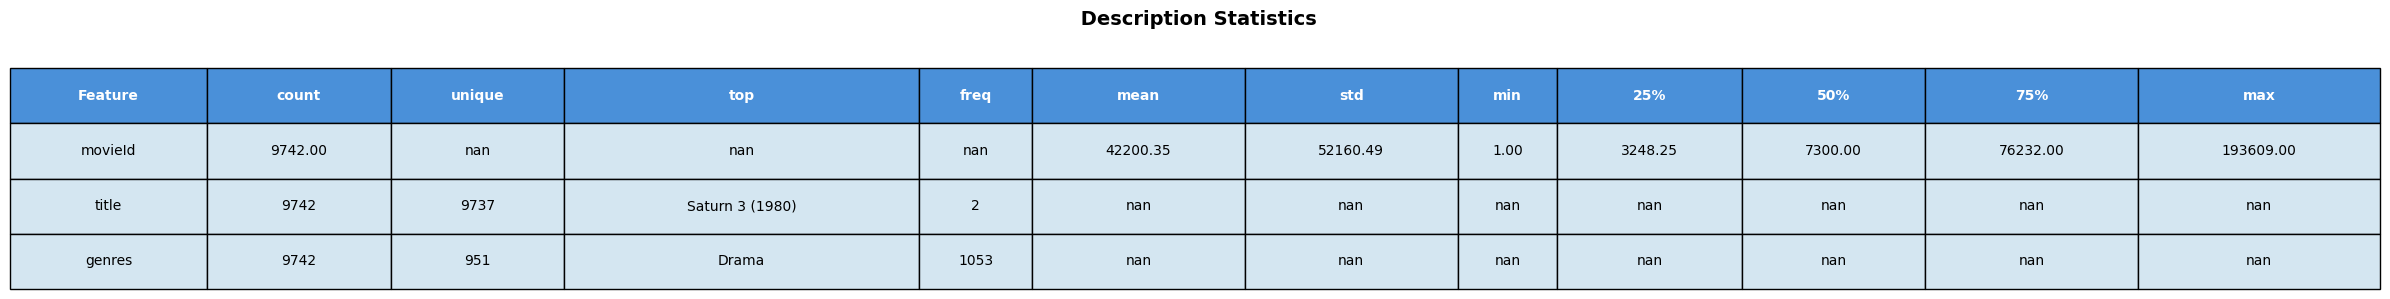

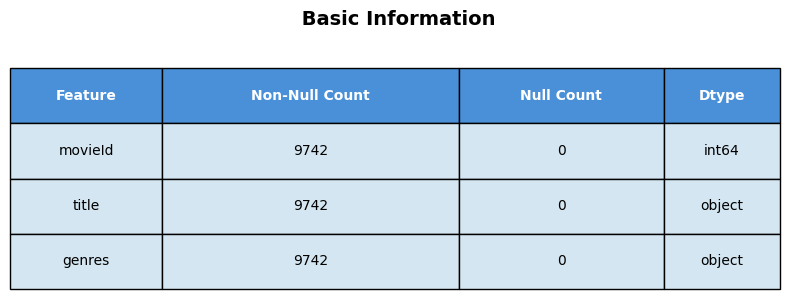

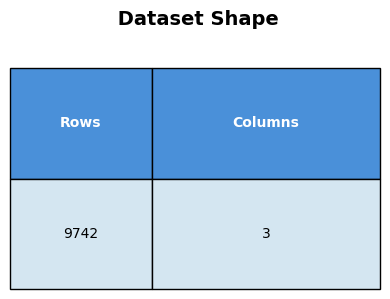




No data to display:  Missing Categorical (String) Data

No data to display:  Missing Numeric Data



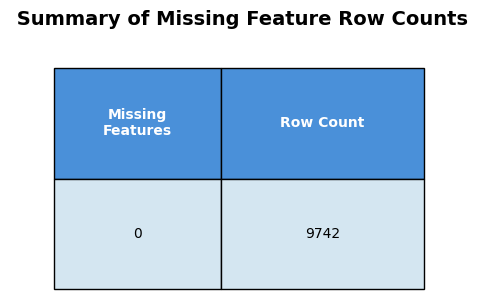

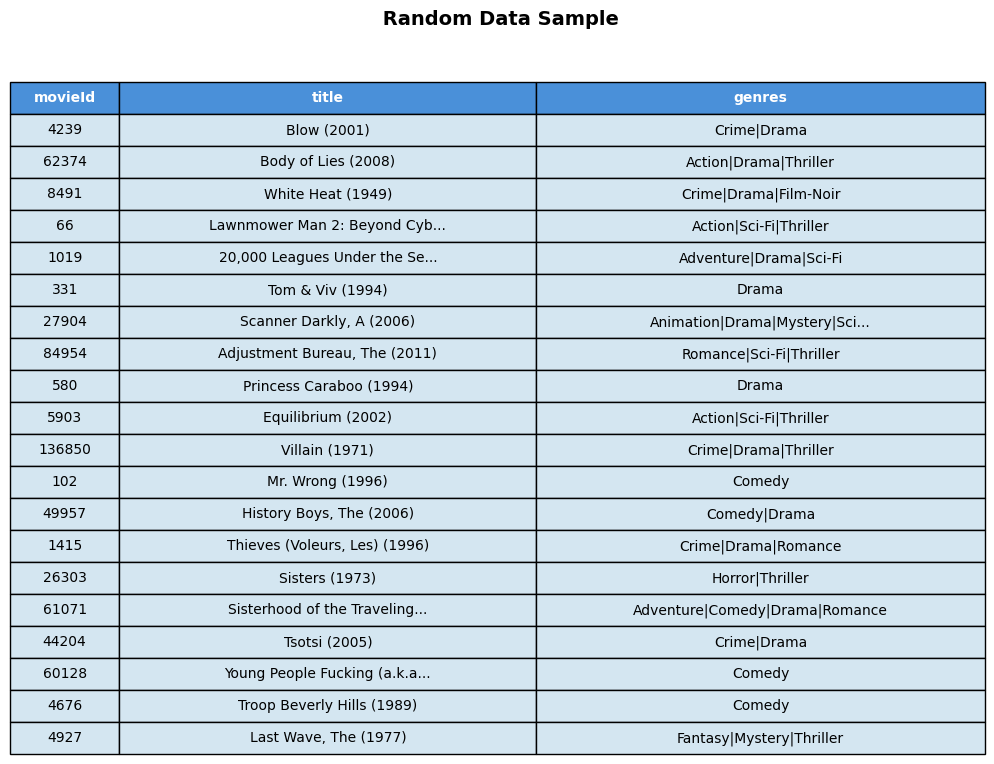




Ratings Data
***********************************
Description Stats
***********************************

     Feature     count          mean           std          min           25%  \
0     userId  100836.0  3.261276e+02  1.826185e+02          1.0  1.770000e+02   
1    movieId  100836.0  1.943530e+04  3.553099e+04          1.0  1.199000e+03   
2     rating  100836.0  3.501557e+00  1.042529e+00          0.5  3.000000e+00   
3  timestamp  100836.0  1.205946e+09  2.162610e+08  828124615.0  1.019124e+09   

            50%           75%           max  
0  3.250000e+02  4.770000e+02  6.100000e+02  
1  2.991000e+03  8.122000e+03  1.936090e+05  
2  3.500000e+00  4.000000e+00  5.000000e+00  
3  1.186087e+09  1.435994e+09  1.537799e+09  

***********************************
Basic Info of imported data set
***********************************

Dataset Shape:(100836, 4)

Do we have any features with null values?:
False

Do we have any features empty strings?:
userId       False
movieId      Fa

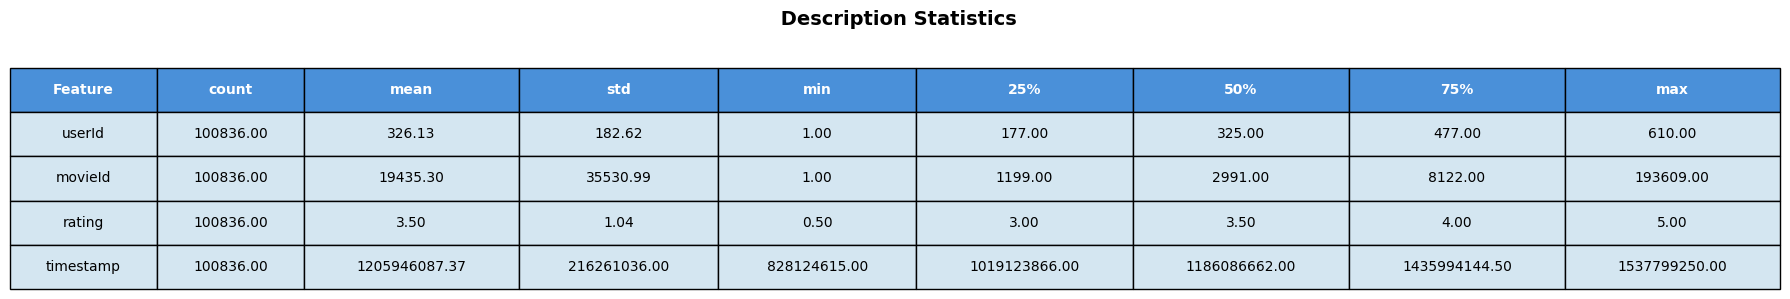

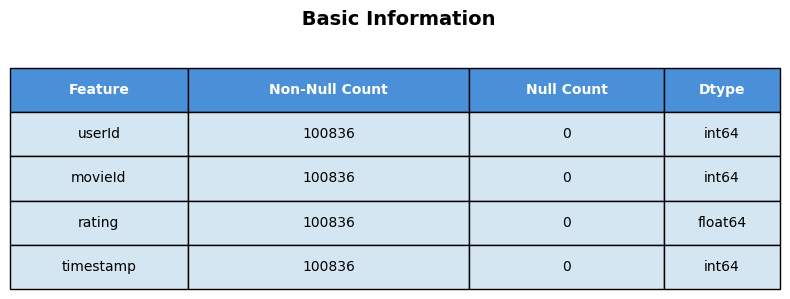

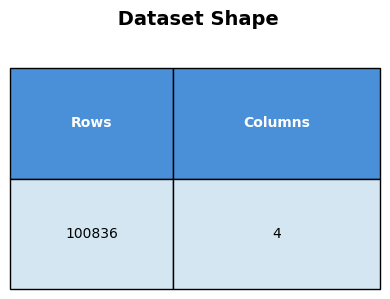




No data to display:  Missing Categorical (String) Data

No data to display:  Missing Numeric Data



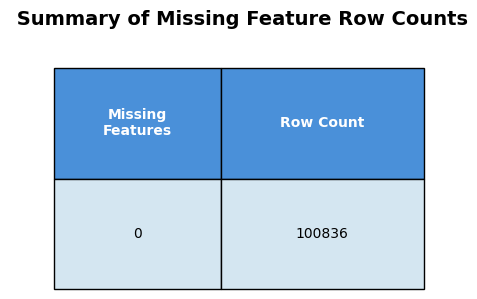

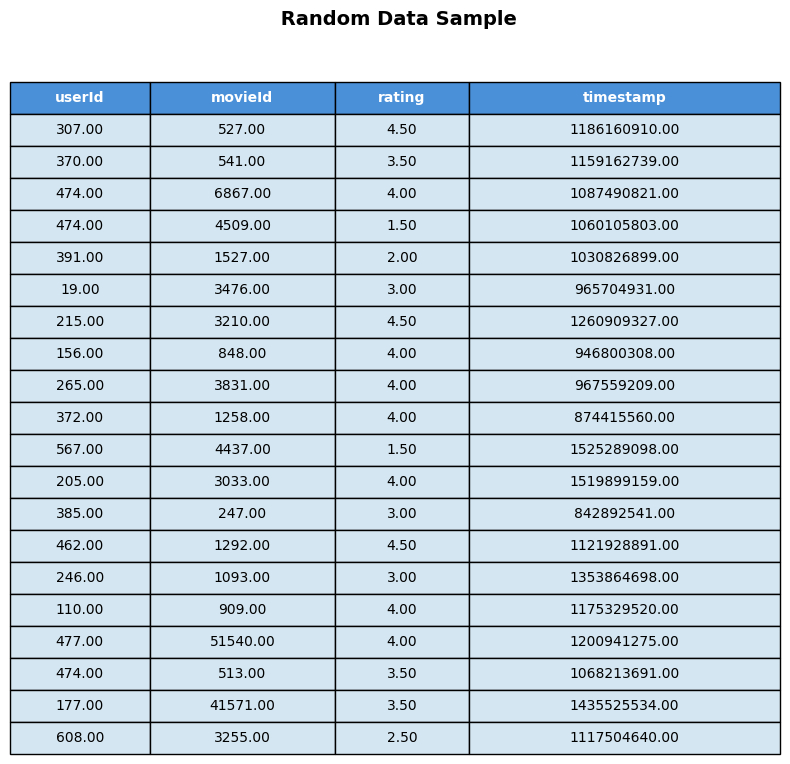

In [174]:
# print out the dataframes stats
print('Movie Data')
PrintDataFrameStatistics(df_Movies)

print('Ratings Data')
PrintDataFrameStatistics(df_Ratings)

### **Initial EDA Analysis** ###
    - Movie Data - 9742 rows of data, 3 features (columns)
    - Ratings Data - 100836 rows of data, 4 features (columns)
    - No rows of missing or (nan) data in either dataset
    - Need to leading/following trim() categorical feature columns

### **Missing Values and Imputation** ###
Not required

##### **Trim Categorical Features** #####

In [175]:
# Movie
obj_cols = df_Movies.select_dtypes(include='object').columns
df_Movies[obj_cols] = df_Movies[obj_cols].apply(lambda col: col.str.strip())

### **New Feature Creation** ###
    - Initial examination of the Movie Dataset indicates we can
        - Split Title Feature into "Title" and "Year Released"
        - Split Genres into separate features using

Unique Movie Genres
Number of Unique Genres: (20, 2)


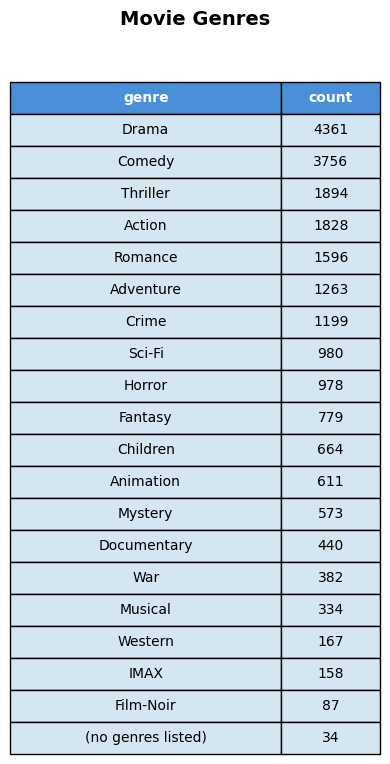

In [176]:
# Genres

# What are the unique genres in the dataset
print('Unique Movie Genres')
df_Genres = df_Movies['genres'].str.split('|').explode().value_counts().reset_index()
df_Genres.columns = ['genre', 'count']
df_Genres['count'] = df_Genres['count'].astype(int)

print(f'Number of Unique Genres: {df_Genres.shape}')
DisplayTable(df_Genres, table_title='Movie Genres')
print()

genres = df_Movies['genres'].str.get_dummies(sep='|')
df_Movies = pd.concat([df_Movies, df_Movies['genres'].str.get_dummies(sep='|')], axis=1)
df_Movies.drop('genres', axis=1, inplace=True)

# Title has the following format: "Movie Title (1999)"
# Title/Year Split - Regex Expressions is best solution
df_Movies['Year'] = df_Movies['title'].str.extract(r'\((\d{4})\)$')

# rsplit() - splits from right to left, so if Title contains (), we don't lose thems
df_Movies['Title'] = df_Movies['title'].str.replace(r'\s*\(\d{4}\)$', '', regex=True)
df_Movies.drop('title', axis=1, inplace=True)

#PrintDataFrameStatistics(df_Movies)

##### **Other interesting eatures we could create..** #####
    - Average Rating per user
    - Number of Ratings per user
    - Average Rating per Movie
    - Number of Ratings per Movie
    - Number of Genres per Movie 

### **Merge Movie and Ratings into Single DataFrame** ###

In [177]:
df_Merged = df_Movies.merge(df_Ratings, left_on='movieId', right_on='movieId')

# Rename column/featurs for consistency
df_Merged.rename(columns={'movieId': 'MovieId'}, inplace=True)
df_Merged.rename(columns={'userId': 'UserId'}, inplace=True)
df_Merged.rename(columns={'rating': 'Rating'}, inplace=True)

#PrintDataFrameStatistics(df_Merged)

#### **Convert timestamp Into Actual DateTime, Year, Month, Day, Hour** ####

***********************************
Description Stats
***********************************

               Feature     count unique           top   freq  \
0              MovieId  100836.0    NaN           NaN    NaN   
1   (no genres listed)  100836.0    NaN           NaN    NaN   
2               Action  100836.0    NaN           NaN    NaN   
3            Adventure  100836.0    NaN           NaN    NaN   
4            Animation  100836.0    NaN           NaN    NaN   
5             Children  100836.0    NaN           NaN    NaN   
6               Comedy  100836.0    NaN           NaN    NaN   
7                Crime  100836.0    NaN           NaN    NaN   
8          Documentary  100836.0    NaN           NaN    NaN   
9                Drama  100836.0    NaN           NaN    NaN   
10             Fantasy  100836.0    NaN           NaN    NaN   
11           Film-Noir  100836.0    NaN           NaN    NaN   
12              Horror  100836.0    NaN           NaN    NaN   
13           

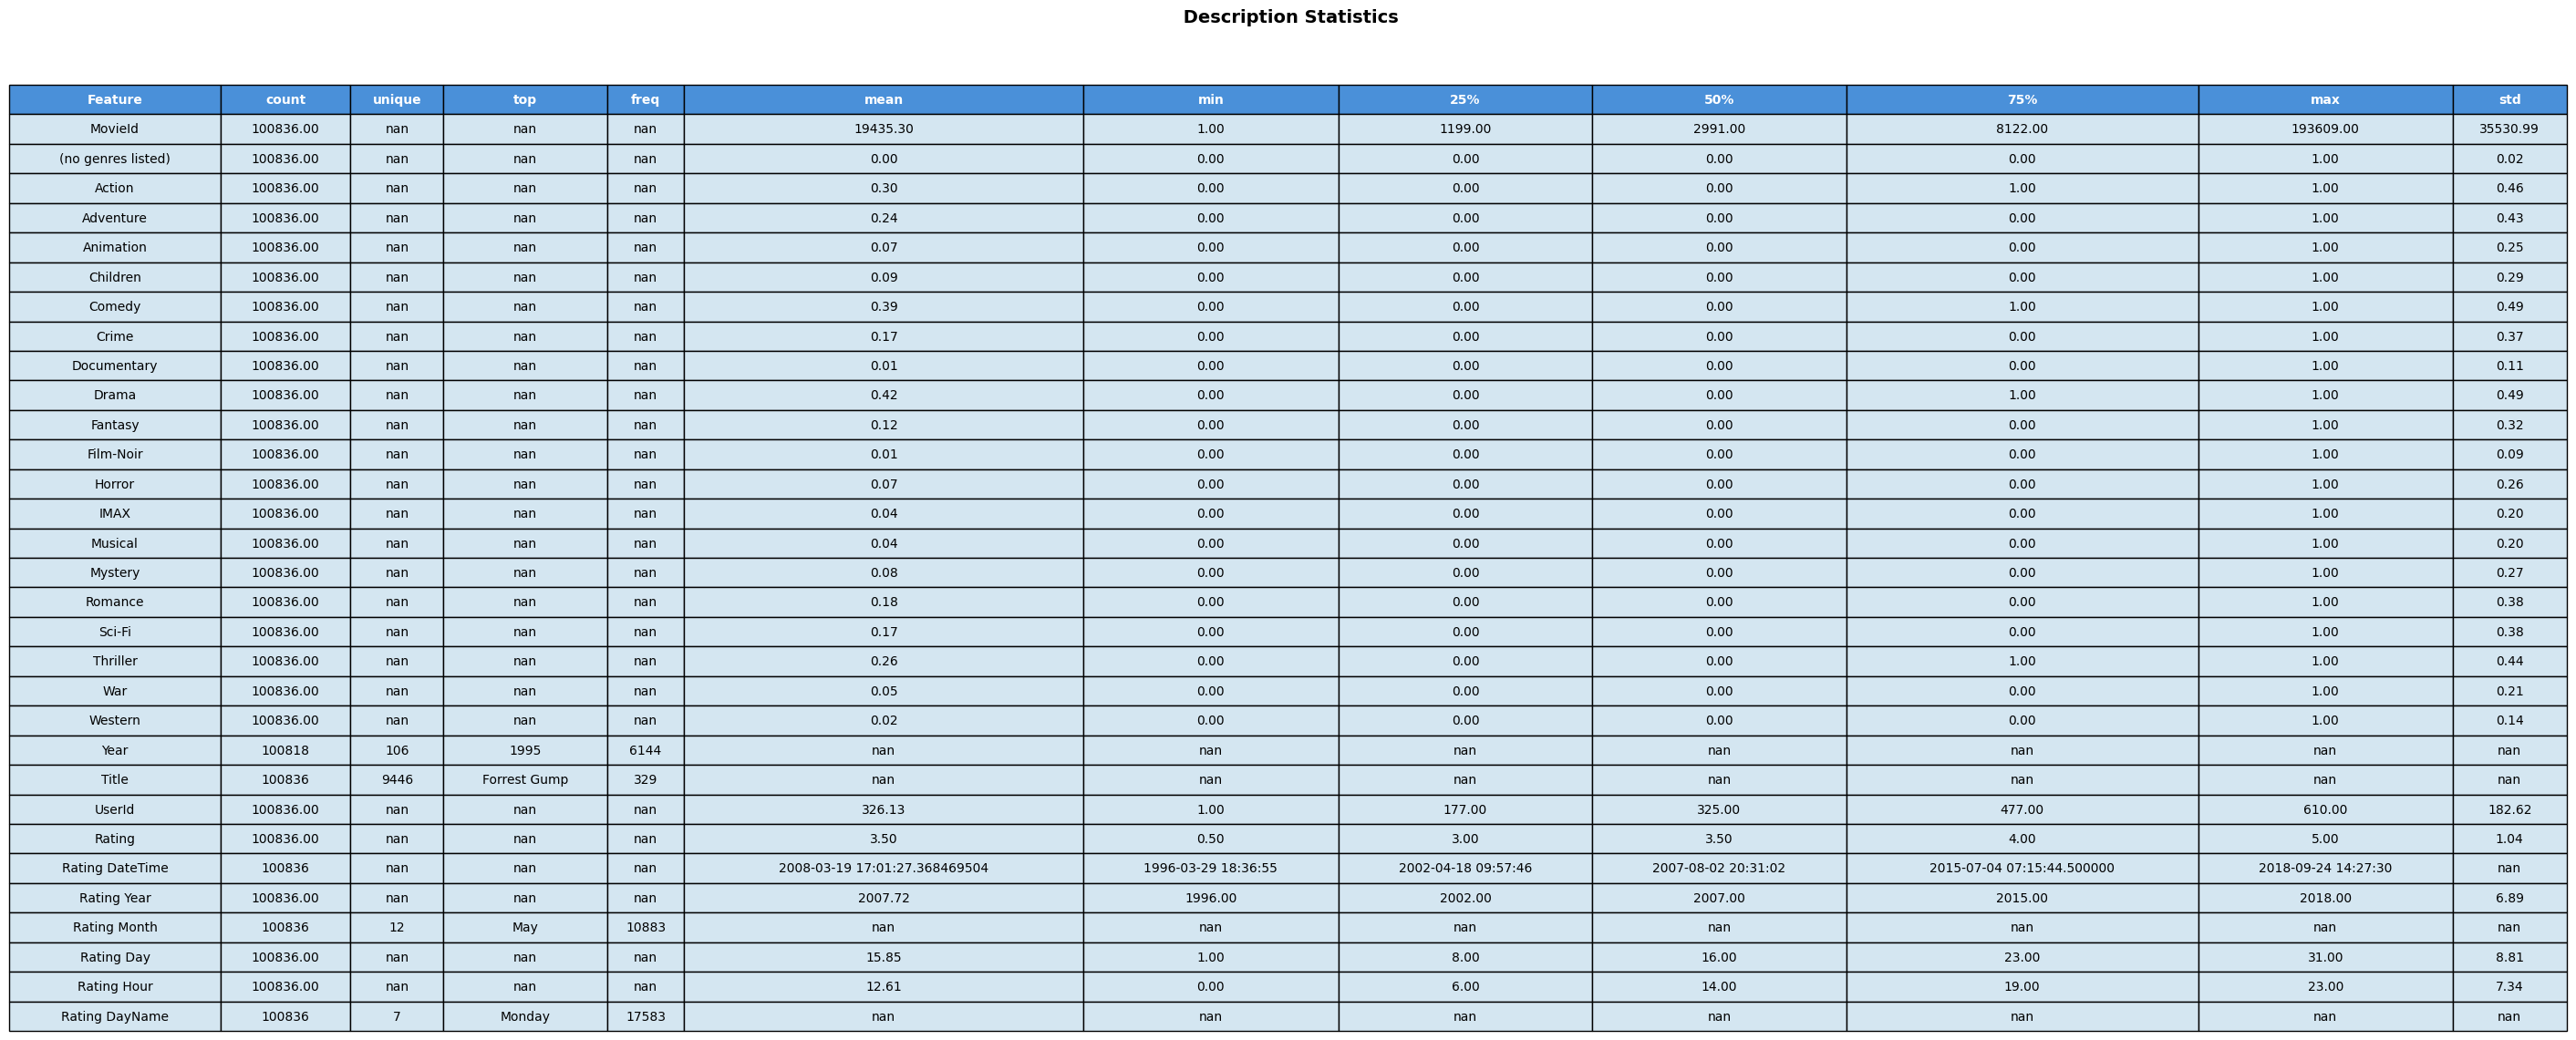

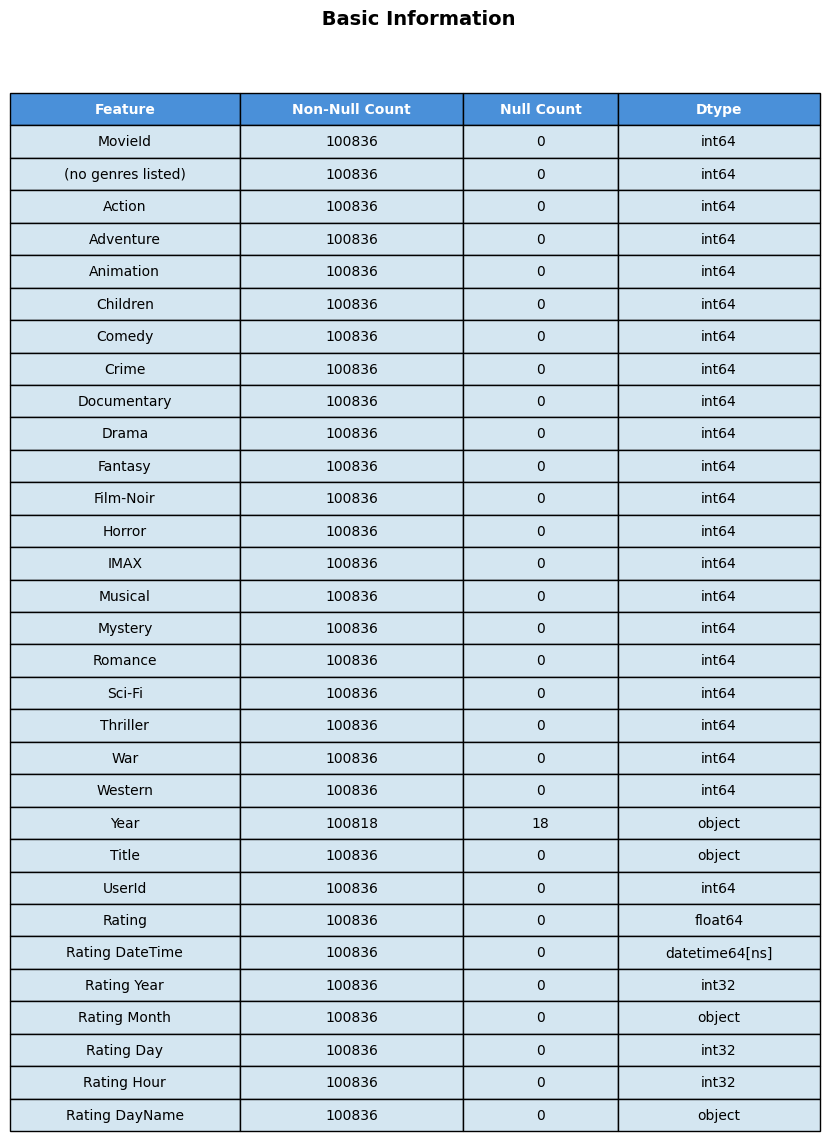

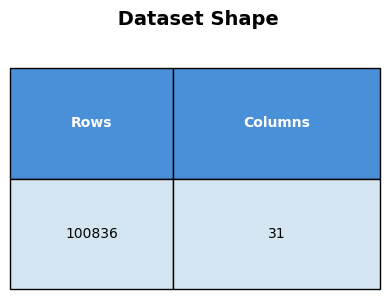

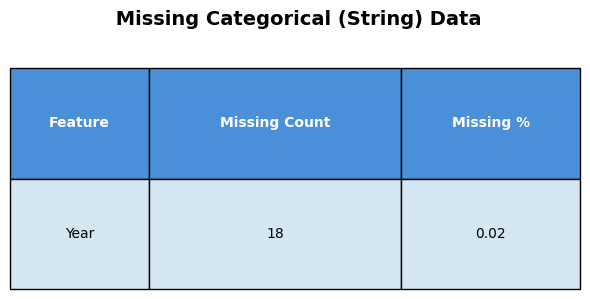




No data to display:  Missing Numeric Data



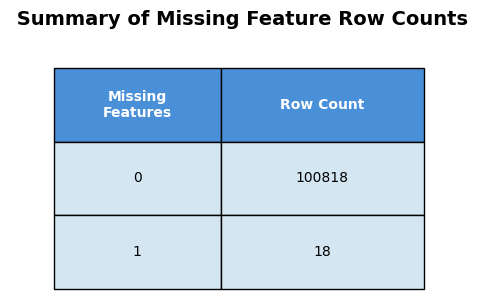

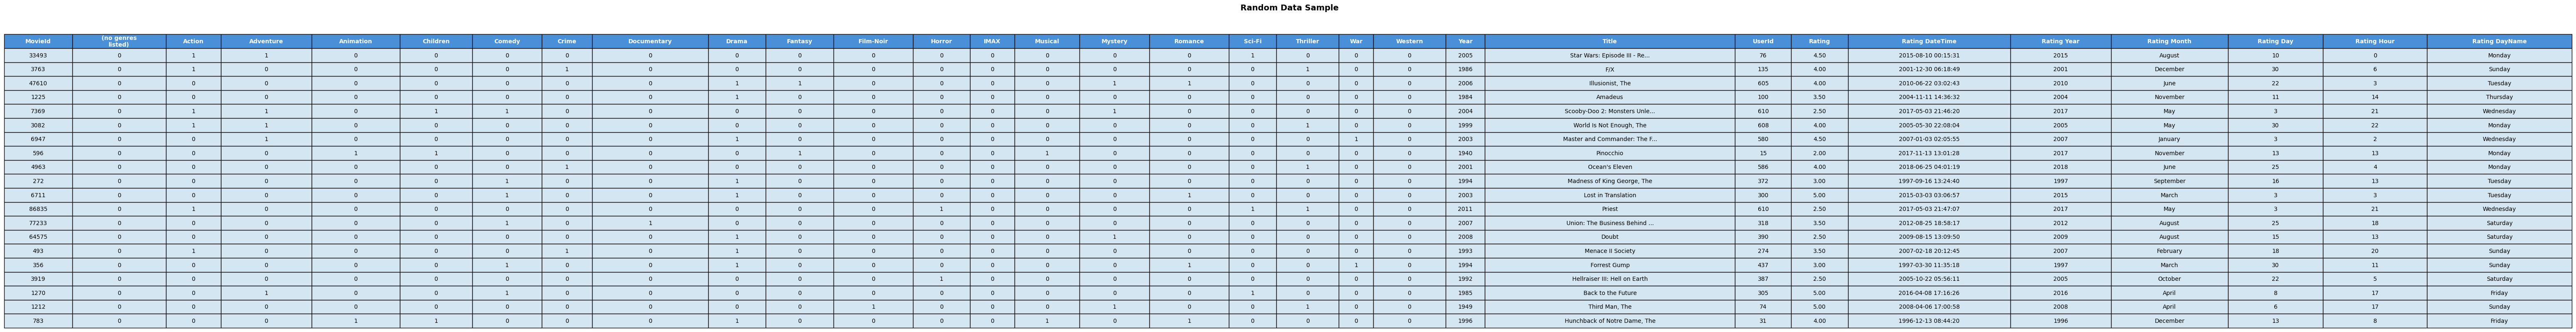

In [178]:
# Convert to DateTime
df_Merged['Rating DateTime'] = pd.to_datetime(df_Merged['timestamp'], unit='s')
df_Merged.drop('timestamp', axis=1, inplace=True)

df_Merged['Rating Year'] = df_Merged['Rating DateTime'].dt.year       
df_Merged['Rating Month'] = df_Merged['Rating DateTime'].dt.month_name()       
df_Merged['Rating Day'] = df_Merged['Rating DateTime'].dt.day         
df_Merged['Rating Hour'] = df_Merged['Rating DateTime'].dt.hour        
df_Merged['Rating DayName'] = df_Merged['Rating DateTime'].dt.day_name()  


PrintDataFrameStatistics(df_Merged)

### **Data Type Conversion** ###
    - For OS memory performance and model efficiency, convert to more efficient data types.

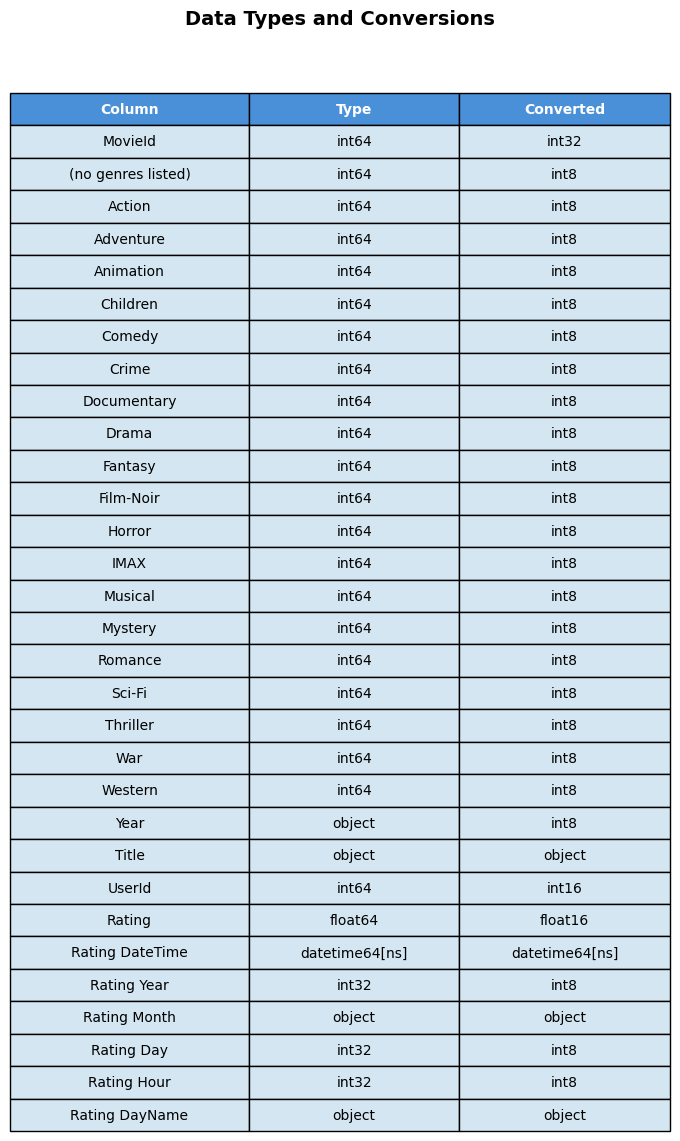




Converted Data Columns


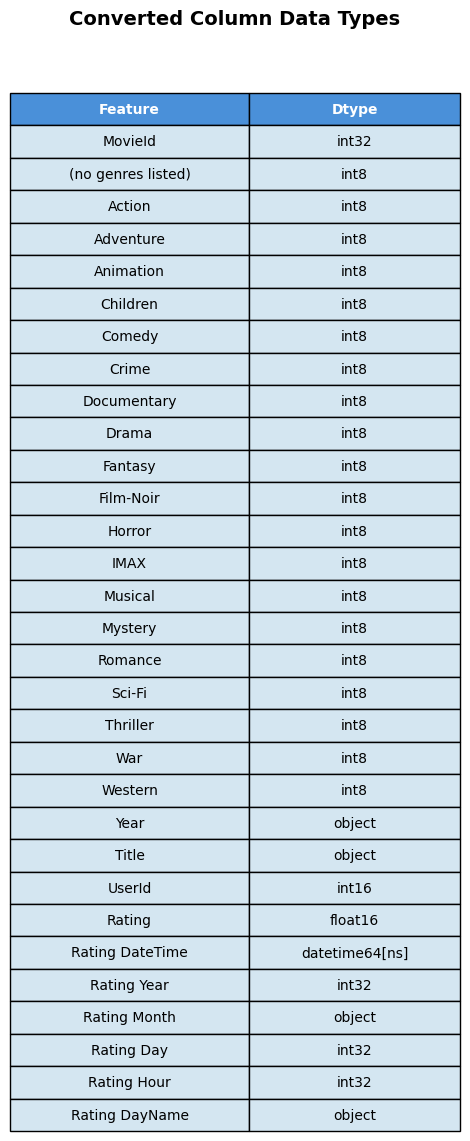

In [179]:
#print(df_Merged.dtypes)


# Features, Types and Data Type Conversion Targets..
df_types = pd.DataFrame({
                    'Column': [
                        'MovieId', '(no genres listed)', 'Action', 'Adventure', 'Animation', 
                        'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 
                        'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 
                        'Sci-Fi', 'Thriller', 'War', 'Western', 'Year', 'Title', 'UserId', 
                        'Rating', 'Rating DateTime', 'Rating Year', 'Rating Month', 
                        'Rating Day', 'Rating Hour', 'Rating DayName'
                    ],
                    'Type': [
                        'int64', 'int64', 'int64', 'int64', 'int64', 'int64', 'int64', 
                        'int64', 'int64', 'int64', 'int64', 'int64', 'int64', 'int64', 
                        'int64', 'int64', 'int64', 'int64', 'int64', 'int64', 'int64', 
                        'object', 'object', 'int64', 'float64', 'datetime64[ns]', 'int32', 
                        'object', 'int32', 'int32', 'object'
                    ],
                    'Converted': [
                        'int32', 'int8', 'int8', 'int8', 'int8', 'int8', 'int8', 
                        'int8', 'int8', 'int8', 'int8', 'int8', 'int8', 'int8', 
                        'int8', 'int8', 'int8', 'int8', 'int8', 'int8', 'int8', 
                        'int8', 'object', 'int16', 'float16', 'datetime64[ns]', 'int8', 
                        'object', 'int8', 'int8', 'object'
                    ]
                })


#print(df_types)

DisplayTable(df_types, table_title='Data Types and Conversions', max_cell_length=60)
print()

def PerformDataConversion(df_target, display_output=False):

    # Convert Floats
    float_columns = ['Rating']
    df_target[float_columns] = df_target[float_columns].astype('float16')

    # Convert Int64 to Int32
    int_columns = ['MovieId']
    df_target[int_columns] = df_target[int_columns].astype('int32')

    # Convert Int64 to Int16 
    int_columns = ['UserId']
    df_target[int_columns] = df_target[int_columns].astype('int16')

    # Convert Int64 to Int8 
    int_columns = ['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 
                     'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 
                     'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 
                     'Thriller', 'War', 'Western' ] # 'Year'] #, 'Rating Year', 'Rating Day', 
                    # 'Rating Hour' ]
    df_target[int_columns] = df_target[int_columns].astype('int8')

    if display_output == True:
        print('Converted Data Columns')

        df_info = pd.DataFrame({
                                'Feature': df_target.columns,
                                'Dtype': df_target.dtypes.values
                                }).reset_index(drop=True)
        DisplayTable(df_info, 'Converted Column Data Types')
    
    return df_target

df_Merged = PerformDataConversion(df_Merged, display_output=True)

### **Exploratory Data Analysis** ###

##### **Display Count Plots** #####
    Display some initial Bar/Count Plots to give us an insight into any trends such as:
        - What days, months, years ratings were likely to occur
        - What movie release years the data set is focusing on 

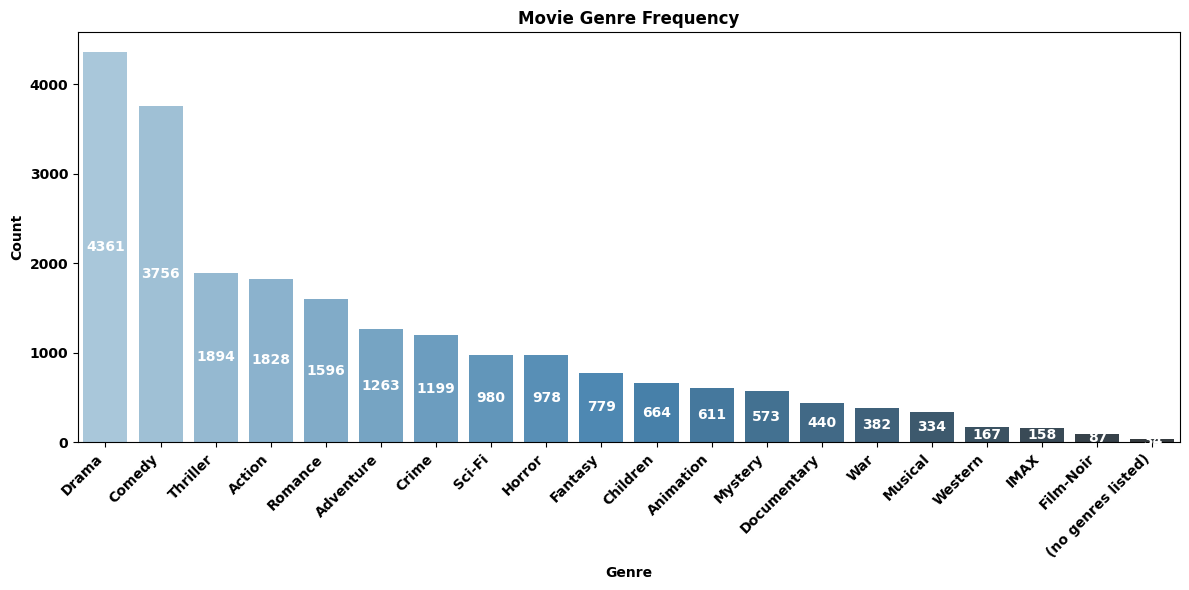

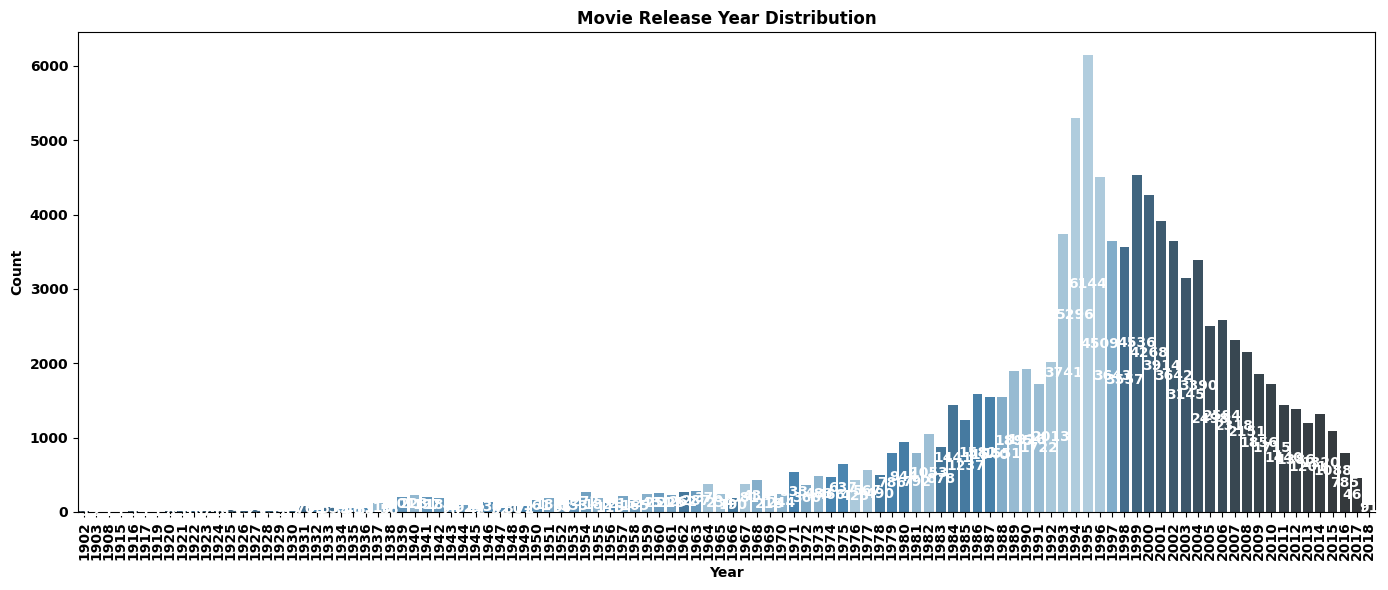

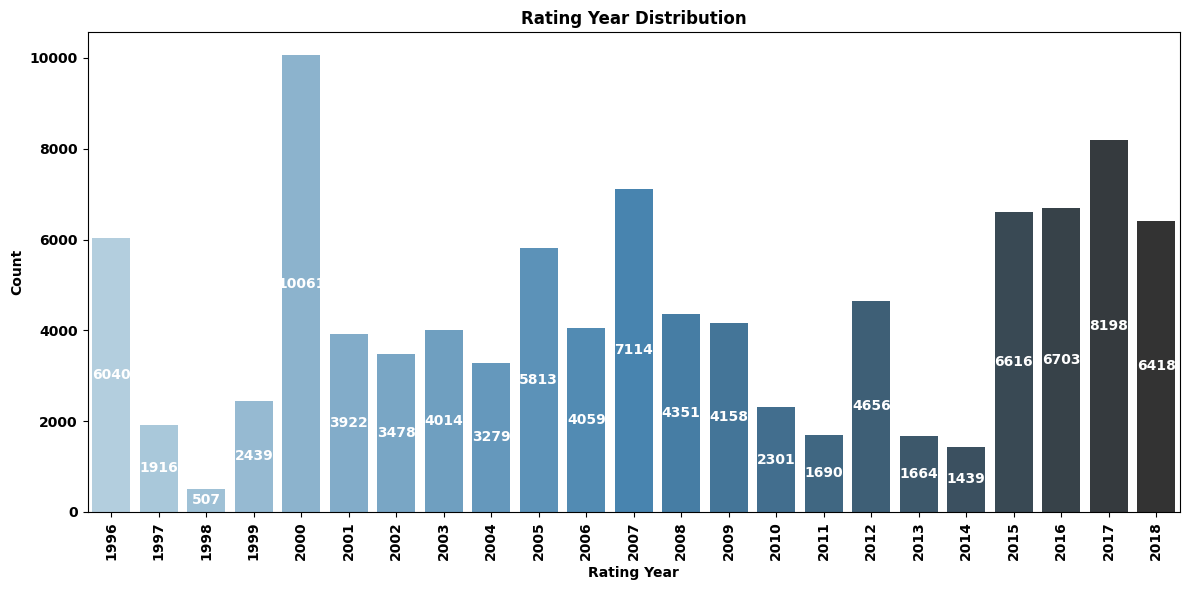

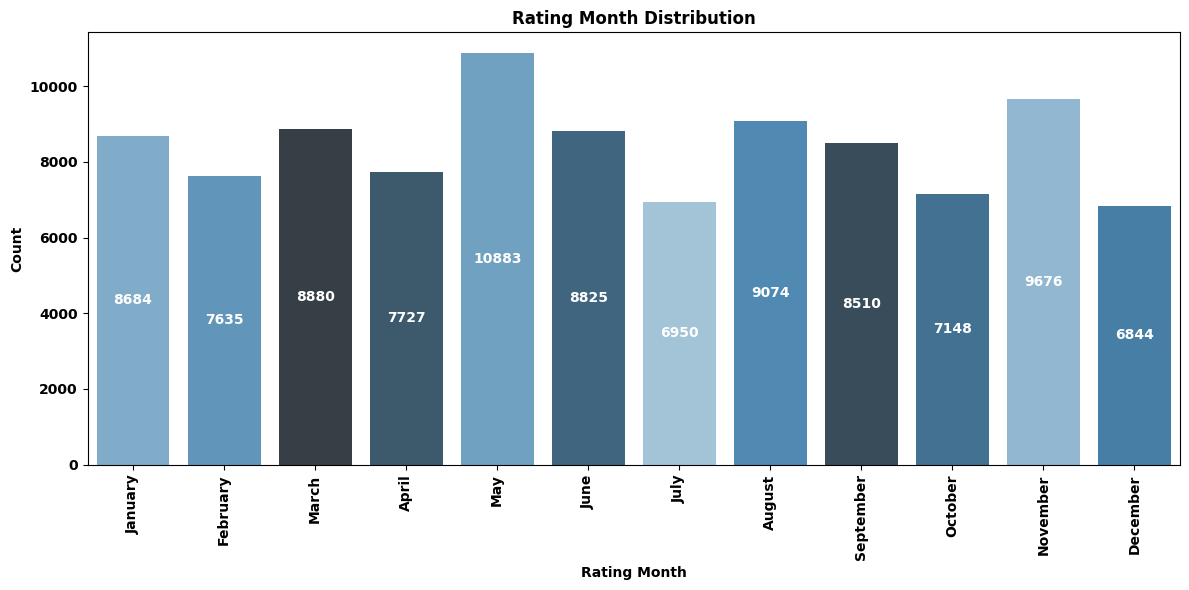

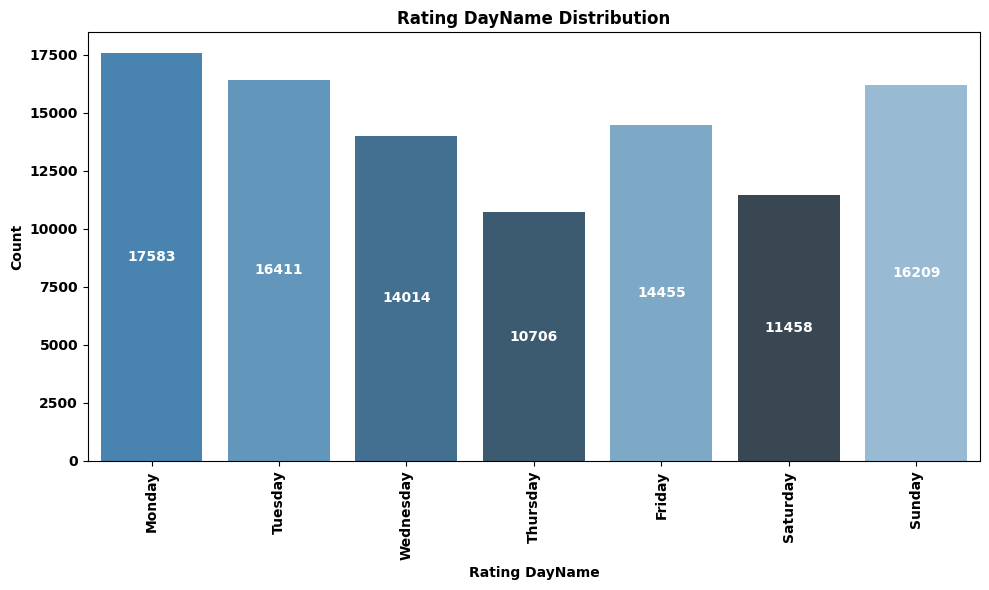

In [180]:
def DisplayBarPlot(df_Target, x_axis, y_axis, plot_title):
    # Plot
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=x_axis, 
                     y=y_axis, 
                     data=df_Target, 
                     hue=x_axis, 
                     palette='Blues_d', 
                     legend=False)

    # Bold title and axis labels
    plt.title(plot_title, fontweight='bold')
    plt.xlabel('Genre', fontweight='bold')
    plt.ylabel('Count', fontweight='bold')

    # Bold tick labels
    plt.xticks(rotation=45, ha='right', fontweight='bold')
    plt.yticks(fontweight='bold')

    # Add white count labels inside bars
    for container in ax.containers:
        ax.bar_label(container, color='white', fontweight='bold', label_type='center', fmt='%.0f')

    plt.tight_layout()
    plt.show()

def DisplayCountPlot(df_Target, x_axis, order, plot_title, fig_size, displayLabels=True):

    plt.figure(figsize=fig_size)
    ax = sns.countplot(x=x_axis, 
                       data=df_Target, 
                       order=order, 
                       hue=x_axis, 
                       palette='Blues_d', 
                       legend=False)

    plt.title(plot_title, fontweight='bold')
    plt.xlabel(x_axis, fontweight='bold')
    plt.ylabel('Count', fontweight='bold')
    plt.xticks(rotation=90, fontweight='bold')
    plt.yticks(fontweight='bold')

    # Skip bar labels for Year (too many bars)
    if displayLabels == True:
        for container in ax.containers:
            ax.bar_label(container, color='white', fontweight='bold', label_type='center')

    plt.tight_layout()
    plt.show()

# Sort by count descending
df_Genres = df_Genres.sort_values('count', ascending=False)
DisplayBarPlot(df_Genres, 'genre', 'count', 'Movie Genre Frequency')

# Year (Movie Release Year)
yearOrder = df_Merged['Year'].value_counts().index.sort_values()
DisplayCountPlot(df_Merged, 'Year', yearOrder, 'Movie Release Year Distribution', (14,6))

# Rating Year
ratingYearOrder = sorted(df_Merged['Rating Year'].unique())
DisplayCountPlot(df_Merged, 'Rating Year', ratingYearOrder, 'Rating Year Distribution', (12,6))

# Rating Month
monthOrder = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
DisplayCountPlot(df_Merged, 'Rating Month', monthOrder, 'Rating Month Distribution', (12,6))

# Rating DayName
dayOrder = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
DisplayCountPlot(df_Merged, 'Rating DayName', dayOrder, 'Rating DayName Distribution', (10,6))


##### **Refined Display Count Plots** #####
    After examining some of the initial plots, they appear to be too busy.
    It's in our best interest to try binning some of the data to make the plots clearer
    and give a clearer view into possible trends.

    NOTE:: Some of the Movie Titles DID NOT INCLUDE Release Year, which is why we are seeing <NA>s plotted

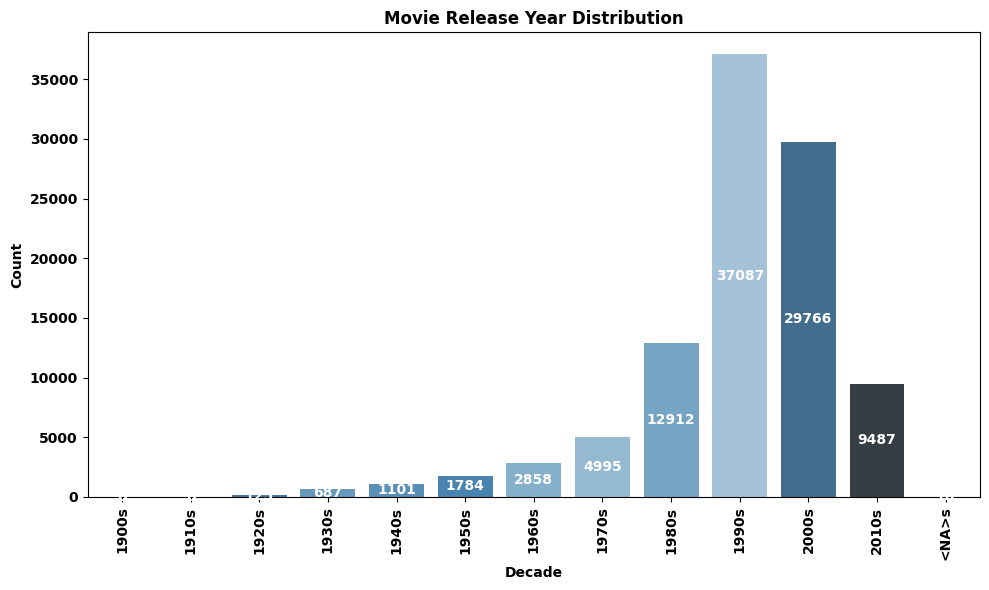

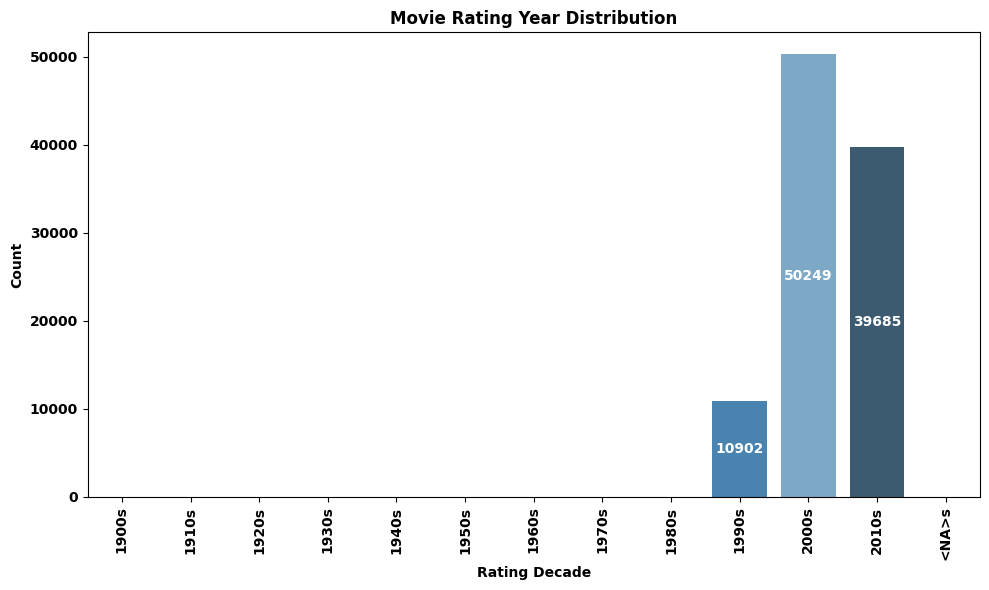

In [181]:
# Bin/Plot Movie Release Years by decades
df_BinnedYears = df_Merged.copy(deep=True)
df_BinnedYears['Decade'] = (df_BinnedYears['Year'].astype(float) // 10 * 10).astype('Int64').astype(str) + 's'

# Check value counts including NaN category
#print(df_Merged[df_Merged['Year'].isna()][['MovieId','Title', 'Year']])
#PrintDataFrameStatistics(df_BinnedYears)

decadesOrder = df_BinnedYears['Decade'].value_counts().index.sort_values()
DisplayCountPlot(df_BinnedYears, 'Decade', decadesOrder, 'Movie Release Year Distribution', (10,6))

# Bin/Plot Movie Review Years
df_BinnedYears['Rating Decade'] = (df_BinnedYears['Rating Year'].astype(float) // 10 * 10).astype('Int64').astype(str) + 's'
DisplayCountPlot(df_BinnedYears, 'Rating Decade', decadesOrder, 'Movie Rating Year Distribution', (10,6))

##### **Display Plot Observations** #####
    - Most of the movies in the dataset were released between 1990s - 2010s
    - All of the movies reviewed/reviewed were between 1990s - 2010s

##### **Examine Ratings per Users** #####

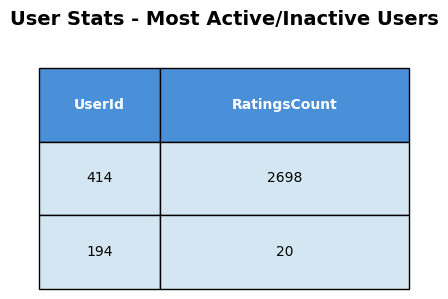

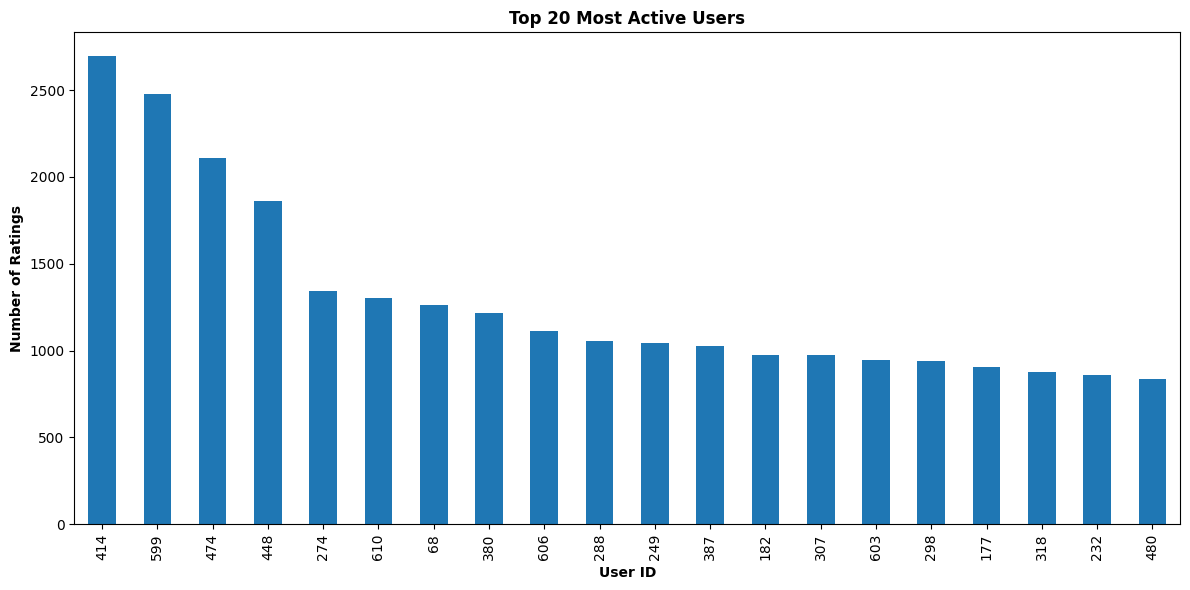

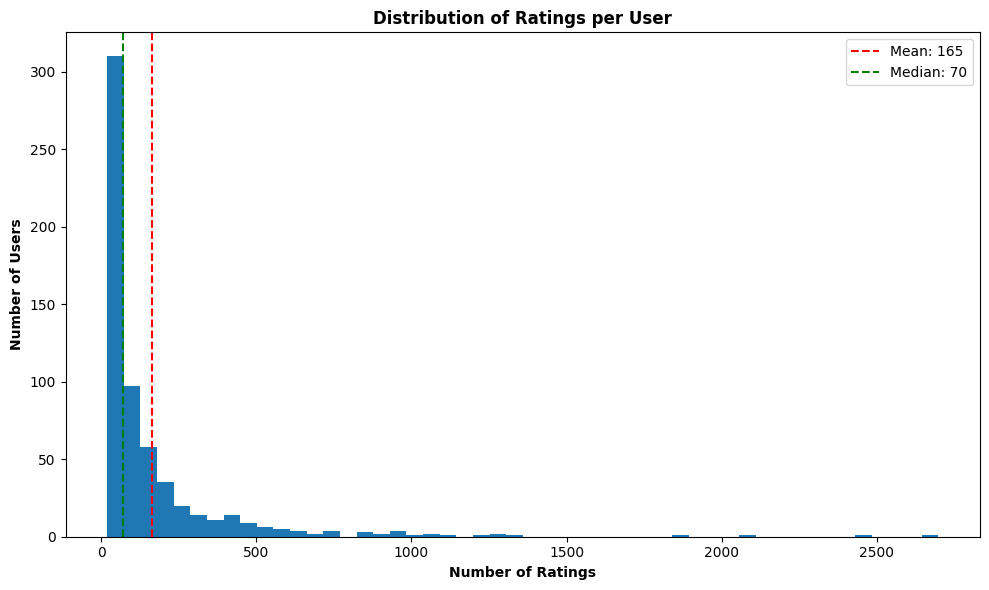

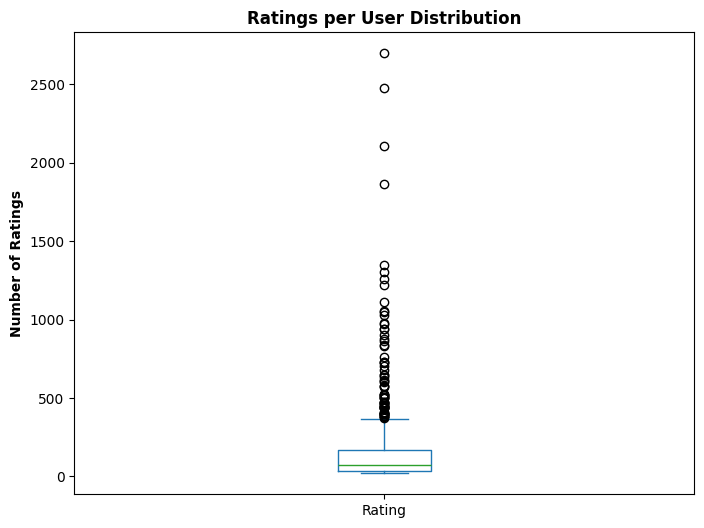

In [182]:
# Count the Ratings per user -- panda series
ratingsPerUser = df_Merged.groupby('UserId')['Rating'].count().sort_values(ascending=False)
# print('Ratings Per User Sample')
# print(ratingsPerUser.head(20))

# Most active/inactive user
df_UserStats = pd.DataFrame({
                                'UserId': [ratingsPerUser.idxmax(), ratingsPerUser.idxmin()],
                                'RatingsCount': [ratingsPerUser.max(), ratingsPerUser.min()]
                            }, index=['Most Active', 'Least Active'])

DisplayTable(df_UserStats, table_title='User Stats - Most Active/Inactive Users')

ratingsPerUser.head(20).plot(kind='bar', figsize=(12, 6))
plt.title('Top 20 Most Active Users', fontweight='bold')
plt.xlabel('User ID', fontweight='bold')
plt.ylabel('Number of Ratings', fontweight='bold')
plt.tight_layout()
plt.show()


# Histogram
plt.figure(figsize=(10, 6))
plt.hist(ratingsPerUser.values, bins='auto')
plt.axvline(ratingsPerUser.mean(), color='red', linestyle='--', label=f'Mean: {ratingsPerUser.mean():.0f}')
plt.axvline(ratingsPerUser.median(), color='green', linestyle='--', label=f'Median: {ratingsPerUser.median():.0f}')
plt.title('Distribution of Ratings per User', fontweight='bold')
plt.xlabel('Number of Ratings', fontweight='bold')
plt.ylabel('Number of Users', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


# Box Plot
ratingsPerUser.plot(kind='box', figsize=(8, 6))
plt.title('Ratings per User Distribution', fontweight='bold')
plt.ylabel('Number of Ratings', fontweight='bold')
plt.show()

print()
print()

##### **Ratings per Users Observations** #####
    - Number of ratings per user Mean: 165
    - Number of ratings per user Median: 70
    - Definite right skewed distribution
    - Most users had less than 165 ratings

##### **Examine Numerical Feature Distributions** #####

c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:51: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:731: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)


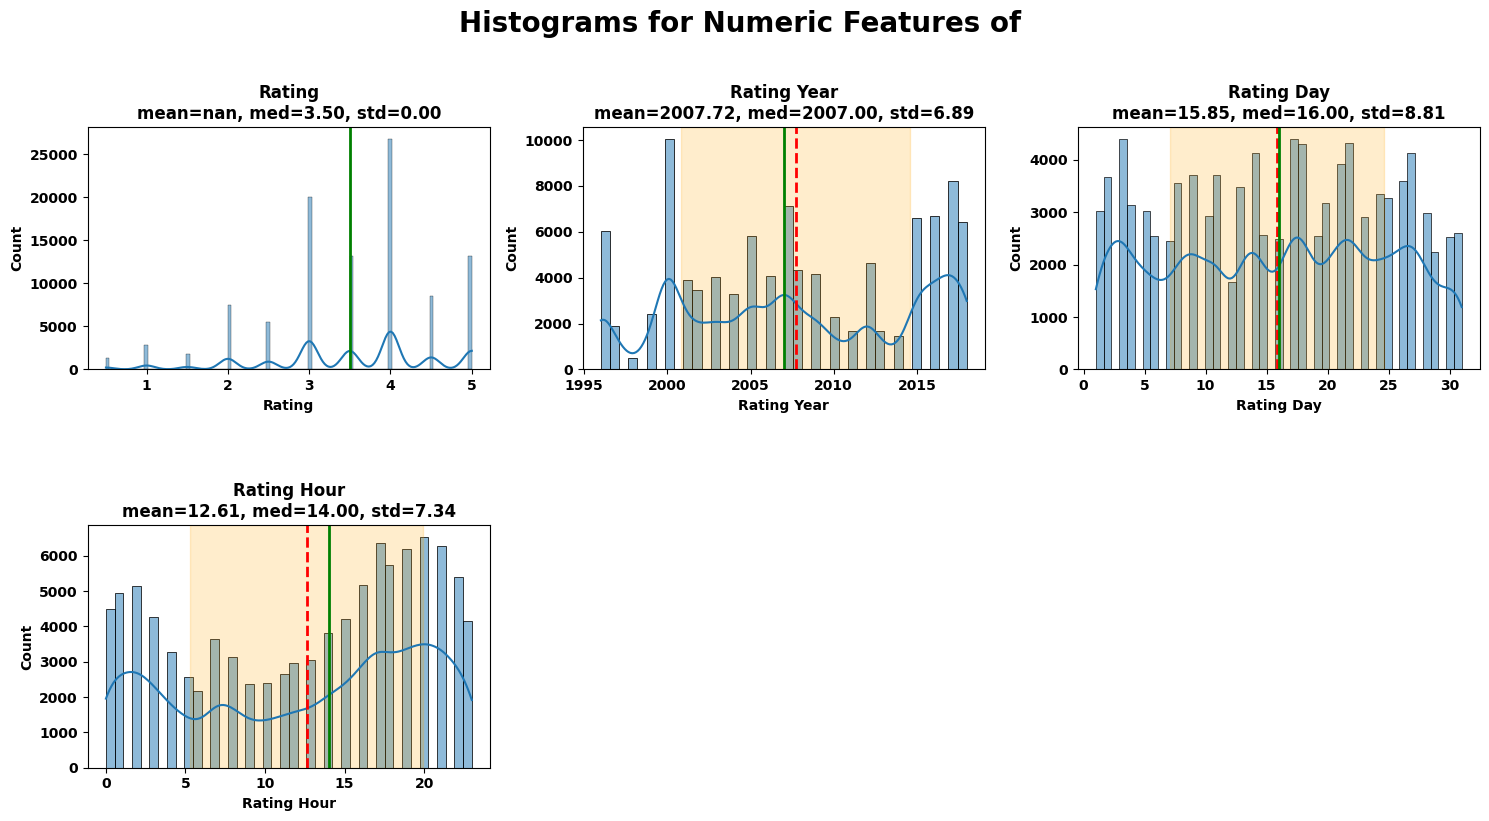

In [183]:
def DisplayNumericFeatureHistograms(df_target, feature_columns = None, target_label=None, plot_title=None, display_statistics=True):

    cols_to_plot = []
    statistics = []
    
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['number']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot = cols_to_plot.drop(target_label).tolist()
    
    number_of_cols = len(cols_to_plot)

    ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
    nrows = (number_of_cols + ncols - 1) // ncols

    # I need a 3 column plot
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    # Iterate over each numeric column and plot a historbram
    for i, col in enumerate(cols_to_plot):

        sns.histplot(data=df_target, x=col, ax=axes[i], kde=True)

        axes[i].set_xlabel(col, fontweight='bold')
        axes[i].set_ylabel('Count', fontweight='bold')
        data = df_target[col]

        if display_statistics == True:

            min_val = data.min()
            max_val = data.max()
            range_val = data.max() - data.min()
            mean_val = data.mean()
            median_val = data.median()
            mode_val = data.mode().tolist()
            std_val = data.std()
            quantile_val = data.quantile([0.25, 0.5, 0.75, 0.90, 0.95]).tolist()
            skew_val = data.skew()
            kurtosis_val = data.kurtosis()

            stats = {
                'Feature': col,
                'Min': min_val,
                'Max': max_val,
                'Mean': mean_val,
                'Median': median_val,
                'Mode': mode_val,
                'Std': std_val,
                'Range': range_val,
                'Quantile': quantile_val,
                'Skew': skew_val,
                'Kurtosis': kurtosis_val
            }            

            statistics.append(stats)

            # print(f'Min Value: {min_val:.3f}')
            # print(f'Max Value: {max_val:.3f}')
            # print(f'Mean Value: {mean_val:.3f}')
            # print(f'Median Value: {median_val:.3f}')
            # print(f'Mode Value: {mode_val}')
            # print(f'Standard Deviation: {std_val:.3f}')
            # print(f'Range Value = {range_val:.3f}')
            # print(f'Quantile Value = {quantile_val}')
            # print(f'Skew Value: {skew_val:.3f}')
            # print(f'Kurtosis Value: {kurtosis_val:.3f}')            

            axes[i].set_title(f'{col}\nmean={mean_val:.2f}, med={median_val:.2f}, std={data.std():.2f}', fontweight='bold')

            # Vertical lines for mean and median, shaded std
            axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
            axes[i].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')            
            axes[i].axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='orange', label=f'±1 Std')

        else:
            axes[i].set_title(f'{col}', fontweight='bold')
        
        # Tick labels in bold
        axes[i].tick_params(axis='both', labelsize=10)
        for label in axes[i].get_xticklabels() + axes[i].get_yticklabels():
            label.set_fontweight('bold')

    # Hide the blank/empty graphs
    for i in range(number_of_cols, len(axes)):
        fig.delaxes(axes[i])

    # Make plots more readable and add space
    title = None
    if plot_title is not None:
        title = plot_title
    else:
        title = f'Histograms for Numeric Features of {data_set_name}'

    plt.suptitle(f'Histograms for Numeric Features of {data_set_name}', y=1.02, fontsize=20, fontweight='bold')
    plt.subplots_adjust(top=0.92)  

    plt.tight_layout(h_pad=5)
    plt.show()  

    print()
    print()

DisplayNumericFeatureHistograms(df_Merged, 
                                feature_columns=['Rating', 'Rating Year', 'Rating Day', 'Rating Hour'],
                                plot_title = 'Ratings Distribution', 
                                display_statistics=True)

##### **Numerical Feature Distribution Observations** #####
    - Ratings tend to be more positive than negative
    - Most Ratings were between 3 and 4
    - Most Ratings occurred 2000 and 2015 - bias of when dataset was created
    - Day of rating pretty evenly distributed
    - Most ratings occurred in the afternoon/evening